# **PROYECTO 2:** ANALÍTICA DE RESULTADOS SABER 11 - HUILA

**Departamento Asignado:** Huila

**Integrantes:** Juan Nicolás Hidalgo, Gabriel Juandedios Prieto, Juan Sebastian Mendez Martinez.

## LIBRERÍAS Y CARGA DE DATOS

In [2]:
# Carga del dataset depurado del Huila (2014-2022)
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

df_analisis = pd.read_csv('../Data/Datos_Huila_Limpio.csv')

Inspección inicial de los primeros 5 registros

In [17]:
df_analisis.head()

,periodo,municipio,naturaleza_colegio,area_colegio,jornada,calendario,enfoque_colegio,genero,estrato,educacion_madre,educacion_padre,tiene_internet,tiene_computador,puntaje_matematicas,puntaje_lectura,puntaje_sociales,puntaje_ciencias,puntaje_ingles,puntaje_global
0,20194,AIPE,OFICIAL,RURAL,COMPLETA,A,TÉCNICO/ACADÉMICO,F,Estrato 2,Postgrado,Primaria completa,Si,Si,66.0,69.0,70.0,65.0,71.0,339.0
1,20194,AIPE,OFICIAL,RURAL,COMPLETA,A,TÉCNICO/ACADÉMICO,F,Estrato 2,Postgrado,Primaria completa,Si,Si,66.0,69.0,70.0,65.0,71.0,339.0
2,20194,LA PLATA,OFICIAL,URBANO,COMPLETA,A,TÉCNICO/ACADÉMICO,F,Estrato 1,Primaria incompleta,Primaria incompleta,No,No,43.0,43.0,31.0,40.0,46.0,199.0
3,20194,LA PLATA,OFICIAL,URBANO,COMPLETA,A,TÉCNICO/ACADÉMICO,F,Estrato 1,Primaria incompleta,Primaria incompleta,No,No,43.0,43.0,31.0,40.0,46.0,199.0
4,20152,ALGECIRAS,OFICIAL,URBANO,SABATINA,A,ACADÉMICO,F,Estrato 1,Primaria incompleta,Primaria incompleta,No,No,44.0,46.0,49.0,43.0,52.0,230.0


## GRÁFICAS

### **Gráfica 1:** Matriz de Correlación

**Dependencia lineal de los componentes evaluados**

Realizamos una matriz de correlación mediante un mapa de calor para determinar si el puntaje global es una combinación lineal de los otros campos evaluados.

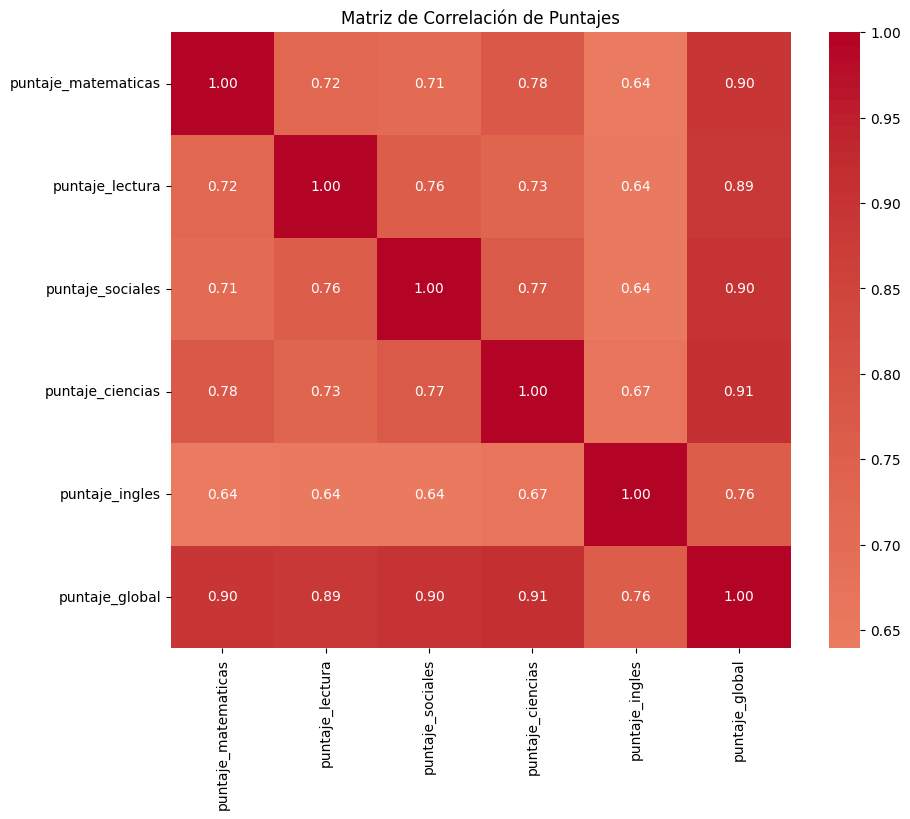

In [18]:
plt.figure(figsize=(10,8))
corr = df_analisis[['puntaje_matematicas','puntaje_lectura',
           'puntaje_sociales','puntaje_ciencias',
           'puntaje_ingles','puntaje_global']].corr()

sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, fmt=".2f")
plt.title("Matriz de Correlación de Puntajes")
plt.show()

#### Conclusiones:
1. Si a un estudiante le va bien en una de estas materias, es casi seguro que tendrá un puntaje global alto. No hay una "materia aislada" que no aporte significativamente al promedio total.
2. Existe una transferencia de habilidades lógica-analíticas. El razonamiento necesario para resolver problemas científicos está muy ligado al éxito en matemáticas, pues en el mapa de calor podemos ver que la relación mas fuerte es entre esas dos (ciencias y matemáticas).
3. Nos damos cuenta de que el componente de ingles resulta depender de factores distintos. Un estudiante puede sobresalir en ciencias o sociales, y eso no garantiza que tenga el mismo nivel de ingles 

### **Gráfica 2:** Distribución por Estrato

**Visualización de la brecha de desigualdad educativa**

Se utiliza un boxplot para comparar el estrato de la vivienda (variable categórica) contra el puntaje global (variable continua).

/var/folders/8b/l0_zh1ls19s_k_7c2c6z3kx00000gn/T/ipykernel_28627/851843998.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='estrato', y='puntaje_global', data=df_analisis, order=orden_estratos, palette='viridis')


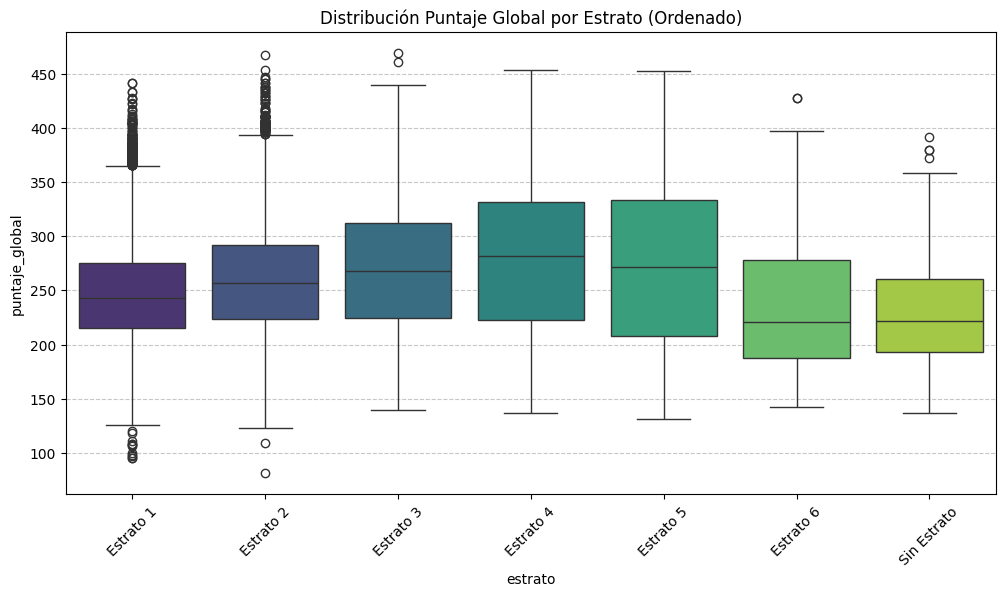

In [19]:
# 1. Definimos el orden lógico de los estratos
orden_estratos = ['Estrato 1', 'Estrato 2', 'Estrato 3', 'Estrato 4', 'Estrato 5', 'Estrato 6', 'Sin Estrato']

# 2. Creamos el gráfico con el parámetro 'order'
plt.figure(figsize=(12, 6))
sns.boxplot(x='estrato', y='puntaje_global', data=df_analisis, order=orden_estratos, palette='viridis')

# 3. Ajustes estéticos
plt.title('Distribución Puntaje Global por Estrato (Ordenado)')
plt.xticks(rotation=45) # Para que los nombres no se traslapen
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

#### Conclusiones:

1. En primer lugar, es logico pensar que a medida que el estrato de la vivienda aumenta, tambien lo hace proporcionalmente el puntaje global, sin embargo, graficando nos damos cuenta de que no es asi, pues las medianas aumentan progresivamente desde el estrato 1 hasta el 4. Despues de esto, notamos que existe una tendencia a la baja de la mediana, debido a que los estratos 5 y 6 asi lo demuestran.

2. Es importante darse cuenta de los outliers en los estratos 1 y 2, esto nos da a entender que muy poca gente proveniente de estos estratos sociales, son aquellos que logran los mejores puntajes excepcionales en la mayoria de los casos puntajes superiores a 370, e incluso algunos llegando a 450.

3. El estrato 6 muestra un desempeño inferior a los estratos 3, 4 y 5, llegando a tener su mediana del puntaje en alrededor de 220 y 230. 

4. El rango intercuartil de los estratos 3, 4 y 5 es mas grande, por lo que podriamos decir que presentan una mayor dispersión, pues en estos grupos conviven estudiantes con desempeños muy variados, lo que indica que en la clase media el estrato por sí solo no predice el puntaje; influyen otros factores como la calidad del colegio o el esfuerzo individual. 

5. Hablando del rango intercuartil, nos damos cuenta que el "estrato 1" y los "No estrato" tienen las cajas mas compactas en la parte inferior de la gráfica, esto nos podria dar un indicio de que la falta de recursos socioecomicos actua como una barrera la cual tiende a "estandarizar" los resultados hacia la baja, llegando a registrar una menor variabilidad interna.

### **Gráfica 3:** Brecha Digital Geográfica

**Acceso a Internet según el área del colegio**

Mapa de calor de frecuencias para las variables "área_colegio" y "tiene_internet".

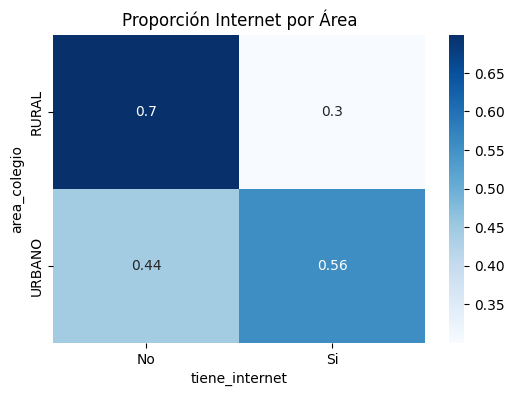

In [20]:
tabla = pd.crosstab(df_analisis['area_colegio'],
                    df_analisis['tiene_internet'],
                    normalize='index')

plt.figure(figsize=(6,4))
sns.heatmap(tabla, annot=True, cmap='Blues')
plt.title("Proporción Internet por Área")
plt.show()

#### Conclusiones:

1. cerca del 70% de los colegios ubicados en zonas rurales no tienen acceso a internet, pues como nos damos cuenta es el punto mas oscuro en nuestra matriz de frecuencia.

2. Ahora bien, en las areas urbanas se podria que decir que esta un poco mas equilibrado, sin embargo, presenta metricas preocupantes pues el 44% de los estudiantes de colegios en zonas rurales no tienen acceso internet 

### **Gráfica 4:** Tecnología y Naturaleza del Plantel

**Disponibilidad de computador en colegios oficiales vs. privados**

Realizamos un diagrama de barras apilado para ver cuantos niños tanto en colegios privados (no oficiales), como en colegios publicos (oficiales) tienen un computador

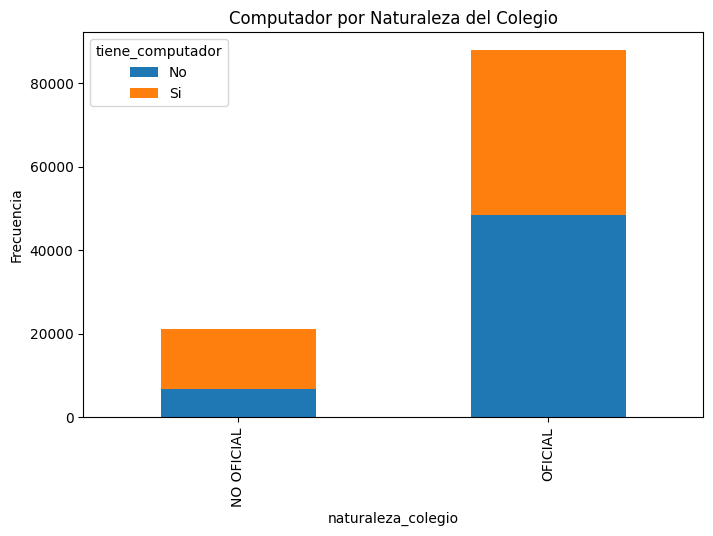

In [21]:
tabla = pd.crosstab(df_analisis['naturaleza_colegio'],
                    df_analisis['tiene_computador'])

tabla.plot(kind='bar', stacked=True, figsize=(8,5))
plt.title("Computador por Naturaleza del Colegio")
plt.ylabel("Frecuencia")
plt.show()

#### Conclusiones:

1. En primer lugar, nos damos cuenta de que cerca del 80% de los estudiantes se encuentra estudiando en un colegio publico (oficial), mientras que alrededor del 20% esta estudiando en un colegio privado.

2. En segundo lugar, nos fijamos que en los colegios privados mas del 50% de los estudiantes tienen un computador, pues la parte naranja es mas grande que la azul, mientras que en los colegios públicos (oficiales) sucede que esta balanceado, pues el tamaño del color naranja (si computador) y el azul (no computador) es casi el mismo.

### **Gráfica 5:** Focalización Estratégica de Municipios

**Relación entre vulnerabilidad y rendimiento promedio**

Gráfico de burbujas para identificar municipios prioritarios para la intervención del Estado.

**Metodología:** Se realizo un gráfico de burbujas, en donde se creo un indice de vulnerabilidad donde 1 significa muy vulnerable y 0 no vulnerable. Esto con el fin de poder saber que municipios son aquellos que tienen mas vulnerabilidad, ademas sacamos el promedio de los puntajes de todos los municipios para saber aquellos lugares en donde aparte de ser vulnerable el promedio del municipio estuvo por debajo del promedio total. Esto para saber en que municipios deberia el estado intervir, pues tienen resultados mas criticos para el promedio global. Por ultimo, mientras mas grande sea la burbuja significa que hay mas estudiantes en ese departamento.

Municipio con más estudiantes: NEIVA


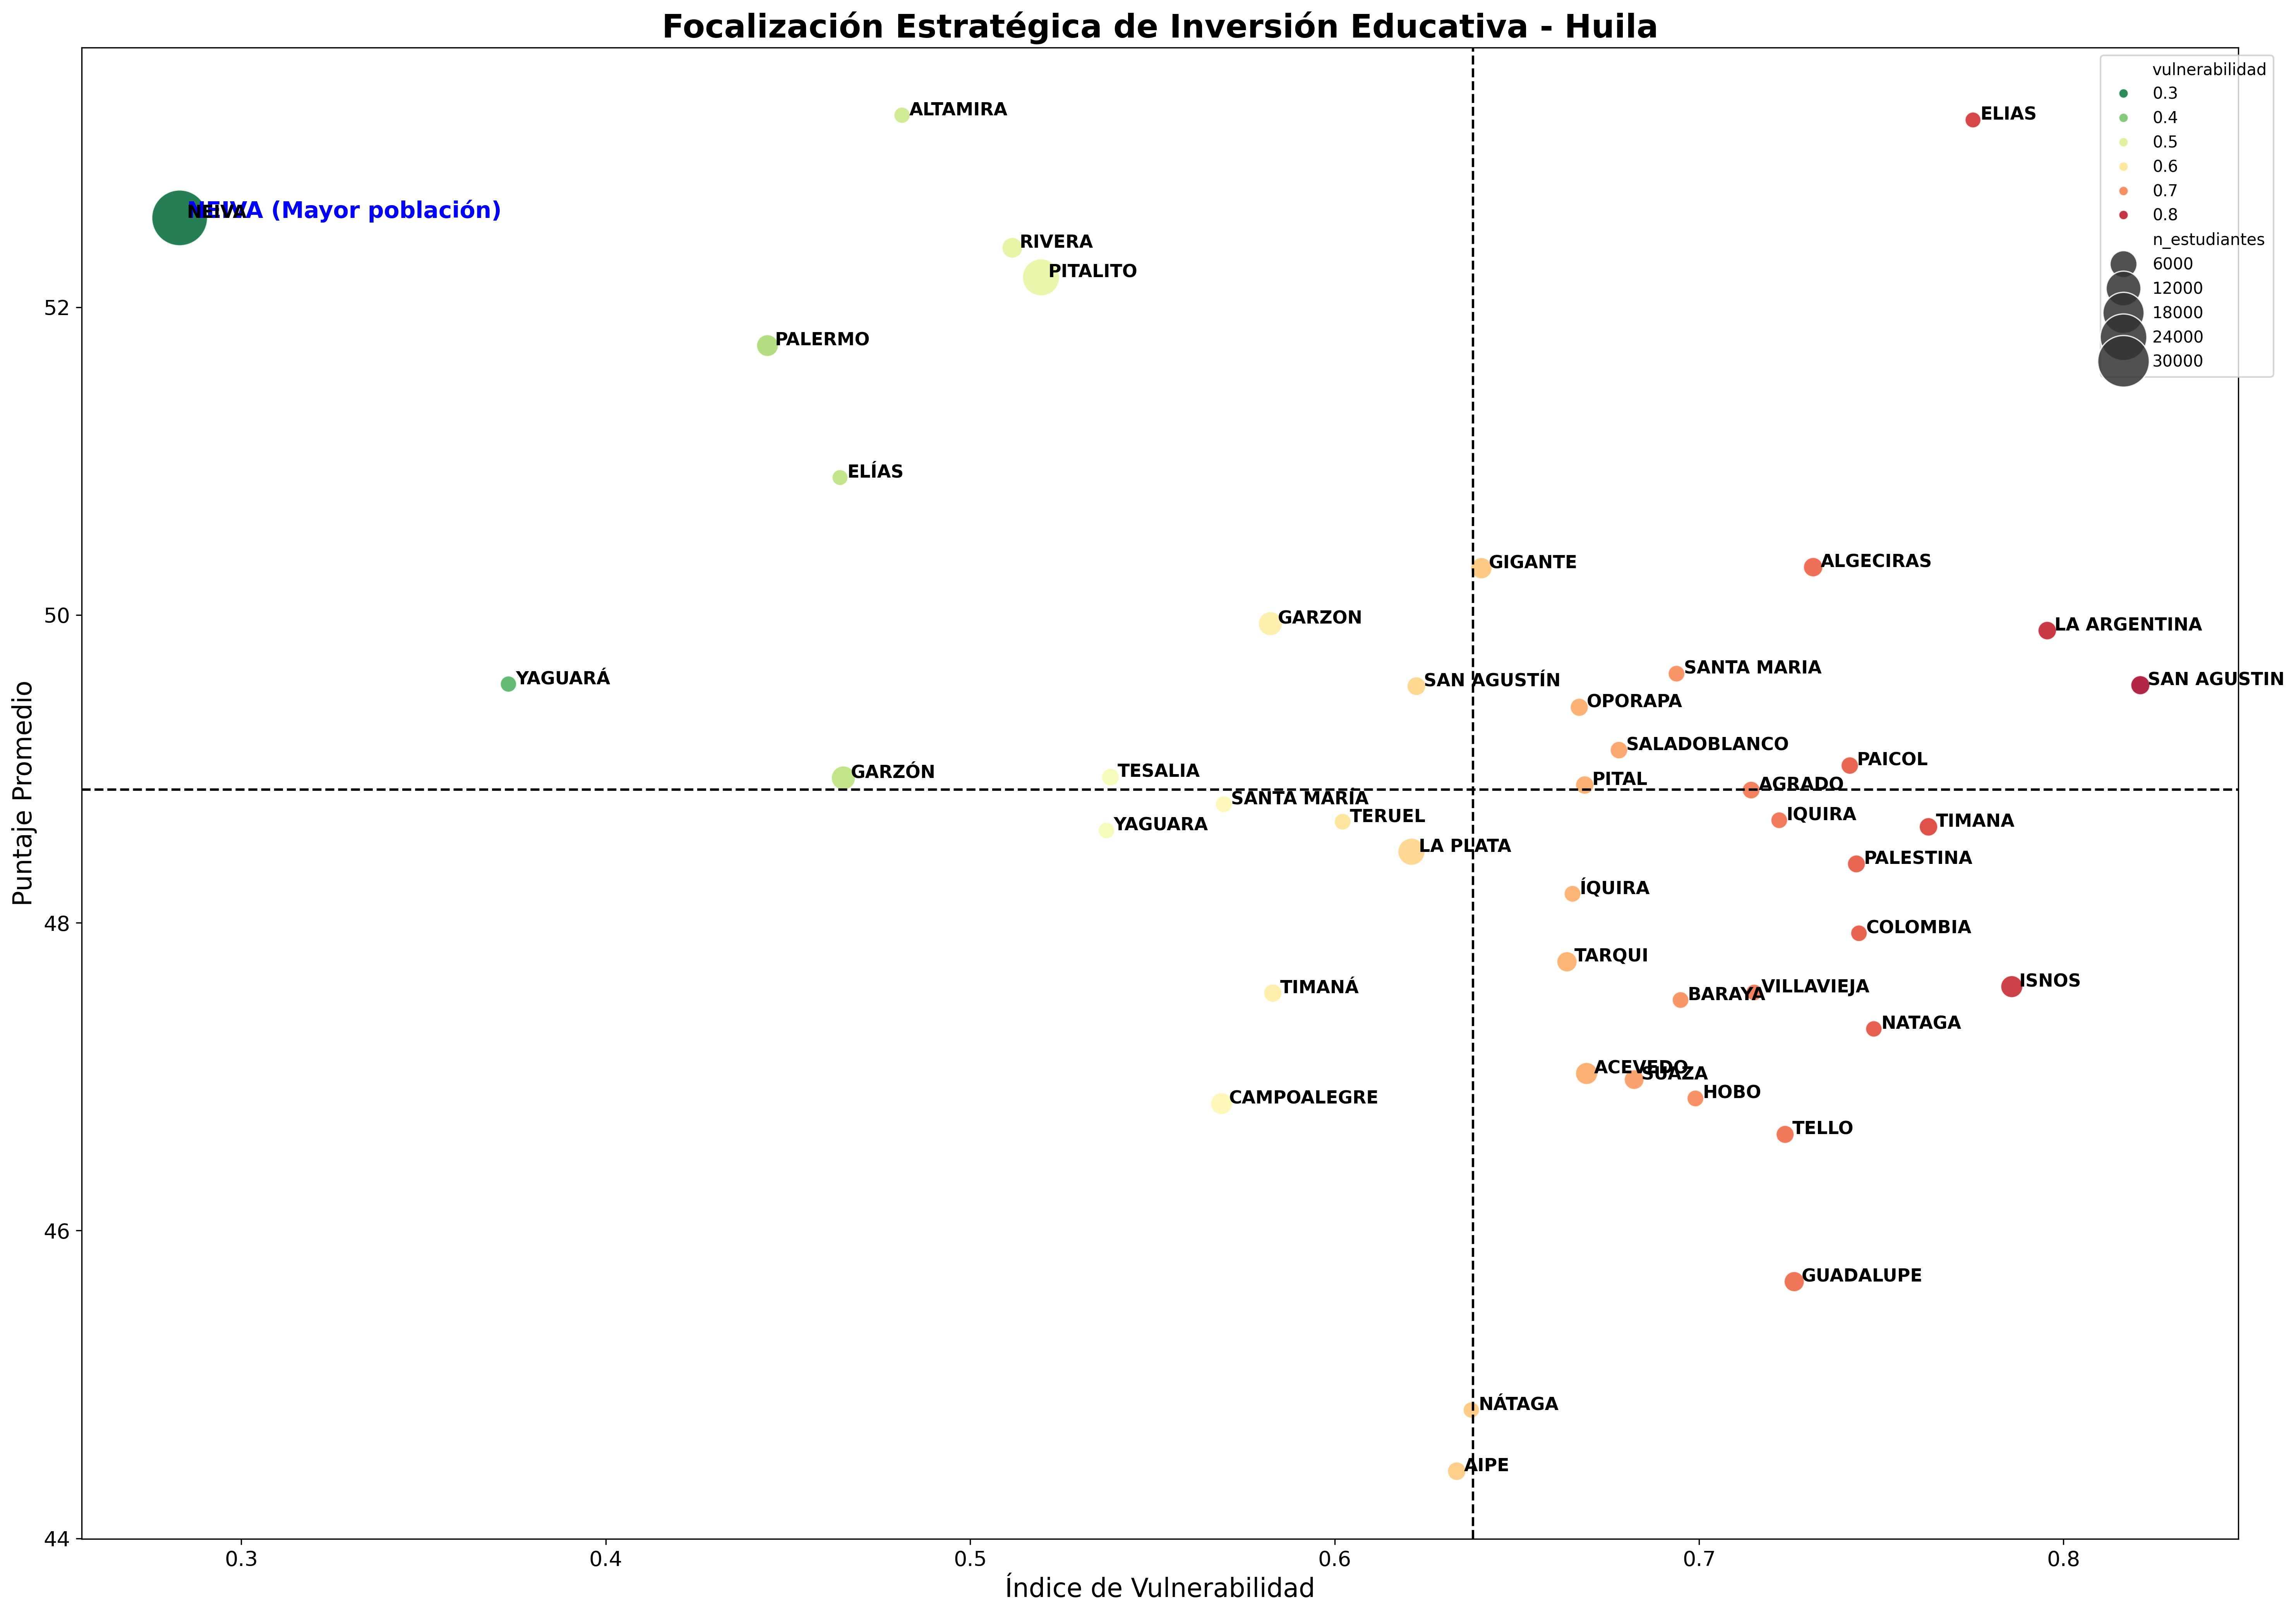

In [22]:
# -----------------------------
# 1. Crear variables binarias
# -----------------------------
df_analisis['internet_bin'] = df_analisis['tiene_internet'].map({'Si':1, 'No':0})
df_analisis['computador_bin'] = df_analisis['tiene_computador'].map({'Si':1, 'No':0})

df_analisis['vulnerabilidad'] = 1 - df_analisis[['internet_bin','computador_bin']].mean(axis=1)

# -----------------------------
# 2. Agregar por municipio (FORMA CORRECTA)
# -----------------------------
municipio = df_analisis.groupby('municipio').agg(
    puntaje_matematicas=('puntaje_matematicas','mean'),
    puntaje_lectura=('puntaje_lectura','mean'),
    puntaje_sociales=('puntaje_sociales','mean'),
    puntaje_ciencias=('puntaje_ciencias','mean'),
    puntaje_ingles=('puntaje_ingles','mean'),
    vulnerabilidad=('vulnerabilidad','mean'),
    n_estudiantes=('municipio','size')
).reset_index()



municipio['puntaje_promedio'] = municipio[
    ['puntaje_matematicas','puntaje_lectura','puntaje_sociales','puntaje_ciencias','puntaje_ingles']
].mean(axis=1)

# -----------------------------
# 3. Identificar municipio con más estudiantes
# -----------------------------
max_municipio = municipio.loc[municipio['n_estudiantes'].idxmax()]

print("Municipio con más estudiantes:", max_municipio['municipio'])

# -----------------------------
# 4. Crear gráfico estratégico
# -----------------------------
plt.figure(figsize=(20,14), dpi=300)

ax = sns.scatterplot(
    data=municipio,
    x='vulnerabilidad',
    y='puntaje_promedio',
    size='n_estudiantes',
    hue='vulnerabilidad',
    palette='RdYlGn_r',
    sizes=(100,1200),
    alpha=0.85
)

# Líneas promedio
plt.axhline(municipio['puntaje_promedio'].mean(), linestyle='--', color='black')
plt.axvline(municipio['vulnerabilidad'].mean(), linestyle='--', color='black')

# -----------------------------
# 5. Etiquetar municipio con más estudiantes
# -----------------------------
plt.text(
    x=max_municipio['vulnerabilidad'] + 0.002,
    y=max_municipio['puntaje_promedio'],
    s=max_municipio['municipio'] + " (Mayor población)",
    fontsize=14,
    weight='bold',
    color='blue'
)

# -----------------------------
# 6. Etiquetar municipios prioritarios
# -----------------------------
prioritarios = municipio[
    (municipio['vulnerabilidad'] >= 0) &
    (municipio['puntaje_promedio'] >=0 )
]

for i in range(prioritarios.shape[0]):
    plt.text(
        x=prioritarios['vulnerabilidad'].iloc[i] + 0.002,
        y=prioritarios['puntaje_promedio'].iloc[i],
        s=prioritarios['municipio'].iloc[i],
        fontsize=11,
        weight='bold'
    )

# -----------------------------
# 7. Estética final
# -----------------------------
plt.title("Focalización Estratégica de Inversión Educativa - Huila",
          fontsize=20, weight='bold')

plt.xlabel("Índice de Vulnerabilidad", fontsize=16)
plt.ylabel("Puntaje Promedio", fontsize=16)

plt.xticks(fontsize=13)
plt.yticks(fontsize=13)

plt.legend(bbox_to_anchor=(1.02,1))
plt.tight_layout()

plt.show()

#### Identificacion de los municipios más criticos:

Al ver el gráfico podemos concluir que Guadalupe, Telo, Isnos, Palestina, Timana, Nataga, Colombia etc., requieren una intervencion inmediata, pues aparte de presentar altos indices de vulnerabilidad, se ubicaron por debajo del puntaje promedio total de los municipios. Por lo que si el Estado decide brindar ayuda a estos municipios podriamos mejorar el promedio deparamental, y hasta impactar de forma positiva a las familias mas vulnerables. 

Se observa una tendencia clara a mentener un puntaje promedio bajo cuando el indice de ulnerabilidad es alto. Por lo que se puede pensar que disminuyendo el indice de vulnerabilidad se pueden mejorar los promedios.

### **Gráfica 6:** Análisis de Brecha de Género

**Diferencias de rendimiento por área de conocimiento**

Realizamos un gráfico de barras con las diferencias promedio entre hombre y mujer para cada área evaluada en la prueba.

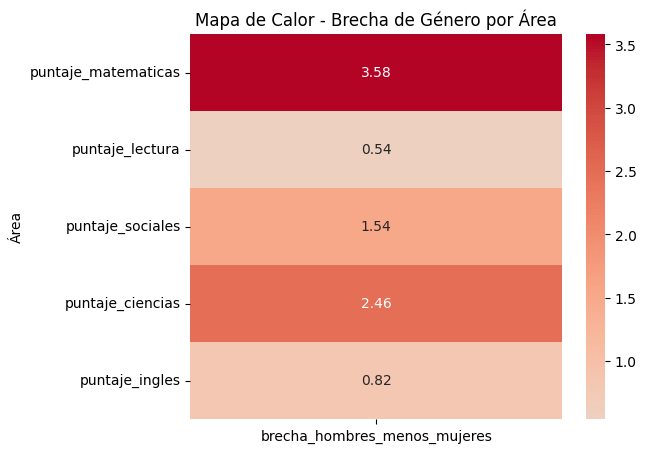

In [ ]:
areas = [
    'puntaje_matematicas',
    'puntaje_lectura',
    'puntaje_sociales',
    'puntaje_ciencias',
    'puntaje_ingles'
]

brechas = []

for area in areas:
    promedio = df_analisis.groupby('genero')[area].mean()
    diferencia = promedio['M'] - promedio['F']
    brechas.append(diferencia)

df_brechas = pd.DataFrame({
    'area': areas,
    'brecha_hombres_menos_mujeres': brechas
})

heatmap_data = df_brechas.set_index('area')

plt.figure(figsize=(6,5))

sns.heatmap(
    heatmap_data,
    annot=True,
    cmap='coolwarm',   
    center=0,          
    fmt=".2f"
)

plt.title("Mapa de Calor - Brecha de Género por Área")
plt.ylabel("Área")
plt.show()

#### Conslusiones y observaciónes:

    1. Se puede observar que para cada área evaluada en el saber 11 los hombres obtuvieron un mayor puntaje promedio, sugiriendo que puede existir una brecha por género en el departamento. 
    2. Notamos que las áreas matemáticas y científicas son las que presentan una mayor magnitud en comparación a las otras áreas.

### **Gráfica 7:** Interacción Estrato y Zona

**Promedio de puntaje global por ubicación y nivel social**

Realizamos un gráfico de barras para observar si pueden existir brechas significativas en el puntaje global dependiendo de la zona y el estrato.

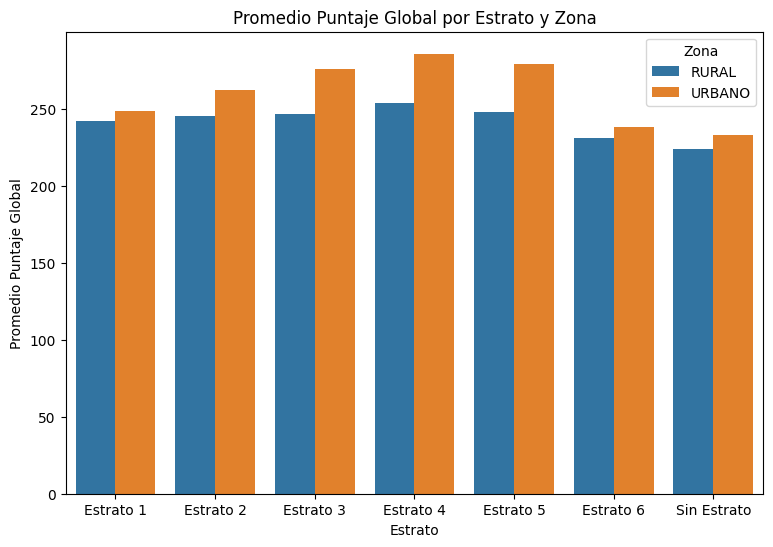

In [24]:
# Agrupar por estrato y zona
df_group = (
    df_analisis.groupby(['estrato', 'area_colegio'])['puntaje_global']
    .mean()
    .reset_index()
)

orden_estratos = ['Estrato 1', 'Estrato 2', 'Estrato 3', 'Estrato 4', 'Estrato 5', 'Estrato 6', 'Sin Estrato']

plt.figure(figsize=(9,6))

sns.barplot(
    data=df_group,
    x='estrato',
    y='puntaje_global',
    hue='area_colegio'
)

plt.title("Promedio Puntaje Global por Estrato y Zona")
plt.xlabel("Estrato")
plt.ylabel("Promedio Puntaje Global")
plt.legend(title="Zona")
plt.show()

#### Conclusión:

    Podemos observar que para todos los estratos el área urbana obtuvo mejores puntajes globales. Además, notamos que los estratos 3,4,5 son aquellos estratos en donde la zona tiene mayores brechas con respecto al puntaje global.


### **Gráfica 8:** Estrato y Género

**Efecto del género en el rendimiento a través de los estratos**

Realizamos un gráfico de lineas para observar si pueden existir brechas significativas en el puntaje global dependiendo de la zona y el genero.

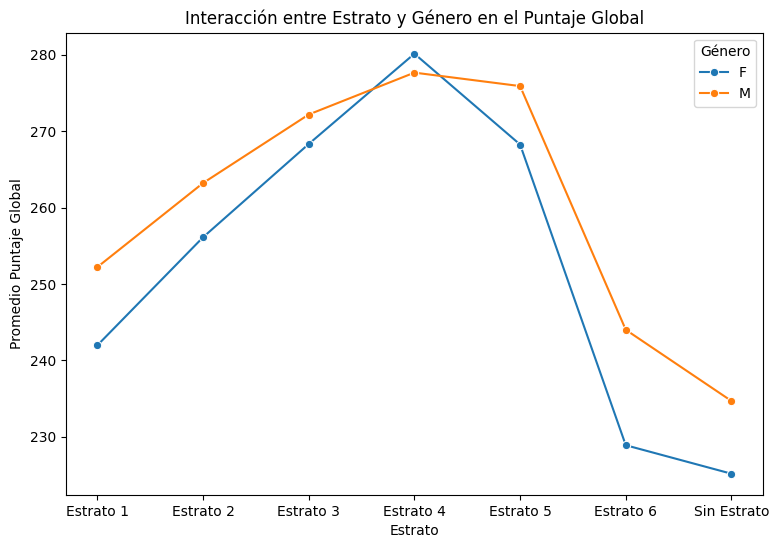

In [25]:
df_group = (
    df_analisis.groupby(['estrato', 'genero'])['puntaje_global']
    .mean()
    .reset_index()
)

plt.figure(figsize=(9,6))

sns.lineplot(
    data=df_group,   
    x='estrato',
    y='puntaje_global',
    hue='genero',
    marker='o'
)

plt.title("Interacción entre Estrato y Género en el Puntaje Global")
plt.xlabel("Estrato")
plt.ylabel("Promedio Puntaje Global")
plt.legend(title="Género")
plt.show()

### **Gráfica 9:** Evolución Histórica Territorial


**Tendencia temporal del puntaje: Oficial vs. No Oficial**

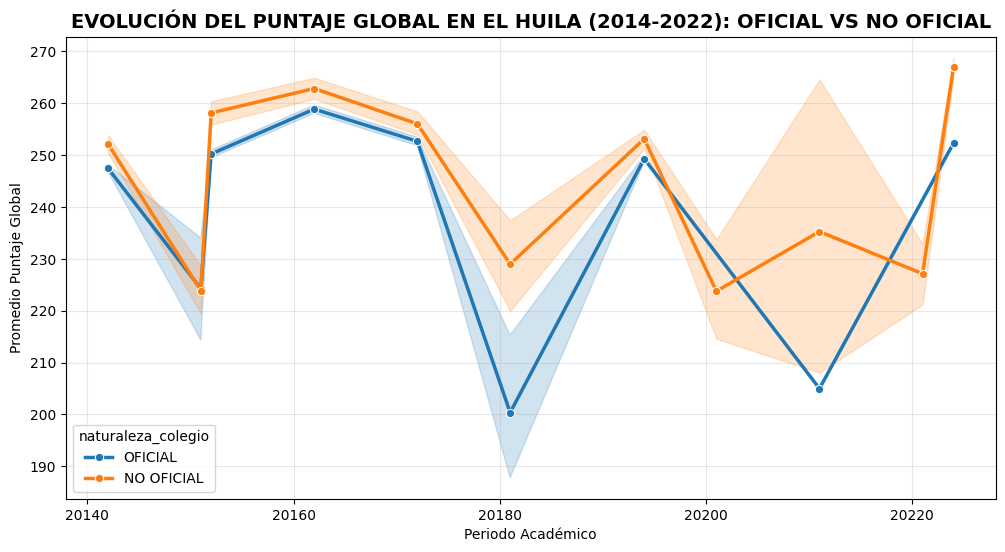

In [26]:
## 8va Gráfica: Evolución Temporal del Puntaje Global por Naturaleza
plt.figure(figsize=(12, 6))
sns.lineplot(data=df_analisis, x='periodo', y='puntaje_global', hue='naturaleza_colegio', marker='o', linewidth=2.5)

plt.title('EVOLUCIÓN DEL PUNTAJE GLOBAL EN EL HUILA (2014-2022): OFICIAL VS NO OFICIAL', fontsize=14, fontweight='bold')
plt.xlabel('Periodo Académico')
plt.ylabel('Promedio Puntaje Global')
plt.grid(True, alpha=0.3)
plt.show()

# Conclusión:
# Permite identificar el impacto de eventos externos (como la pandemia) y si la educación privada 
# en el Huila ha logrado mantener una ventaja competitiva o si la educación pública está convergiendo.

### **Gráfica 10:** Jornada Académica

**Impacto del tiempo escolar en el desempeño**

/var/folders/8b/l0_zh1ls19s_k_7c2c6z3kx00000gn/T/ipykernel_28627/4125549788.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='jornada', y='puntaje_global', data=df_analisis, order=order_jornada, palette='Set2')


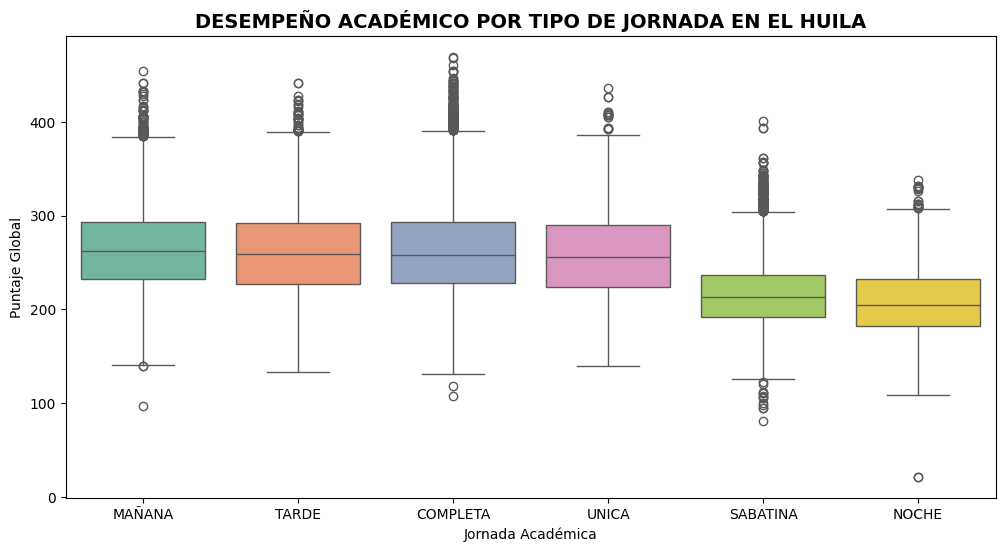

In [27]:
## 9na Gráfica: Impacto de la Jornada Escolar en el Desempeño
plt.figure(figsize=(12, 6))
# Usamos un boxplot pero filtrando por orden de mediana para ver claridad
order_jornada = df_analisis.groupby('jornada')['puntaje_global'].median().sort_values(ascending=False).index

sns.boxplot(x='jornada', y='puntaje_global', data=df_analisis, order=order_jornada, palette='Set2')

plt.title('DESEMPEÑO ACADÉMICO POR TIPO DE JORNADA EN EL HUILA', fontsize=14, fontweight='bold')
plt.xlabel('Jornada Académica')
plt.ylabel('Puntaje Global')
plt.show()

# Conclusión:
# Si la "Jornada Completa" o "Única" tienen medianas significativamente superiores a la "Sabatina" 
# o "Tarde", se tiene evidencia técnica para recomendar la transición de más colegios a jornadas de tiempo completo.

**Relación entre educación materna y éxito académico**

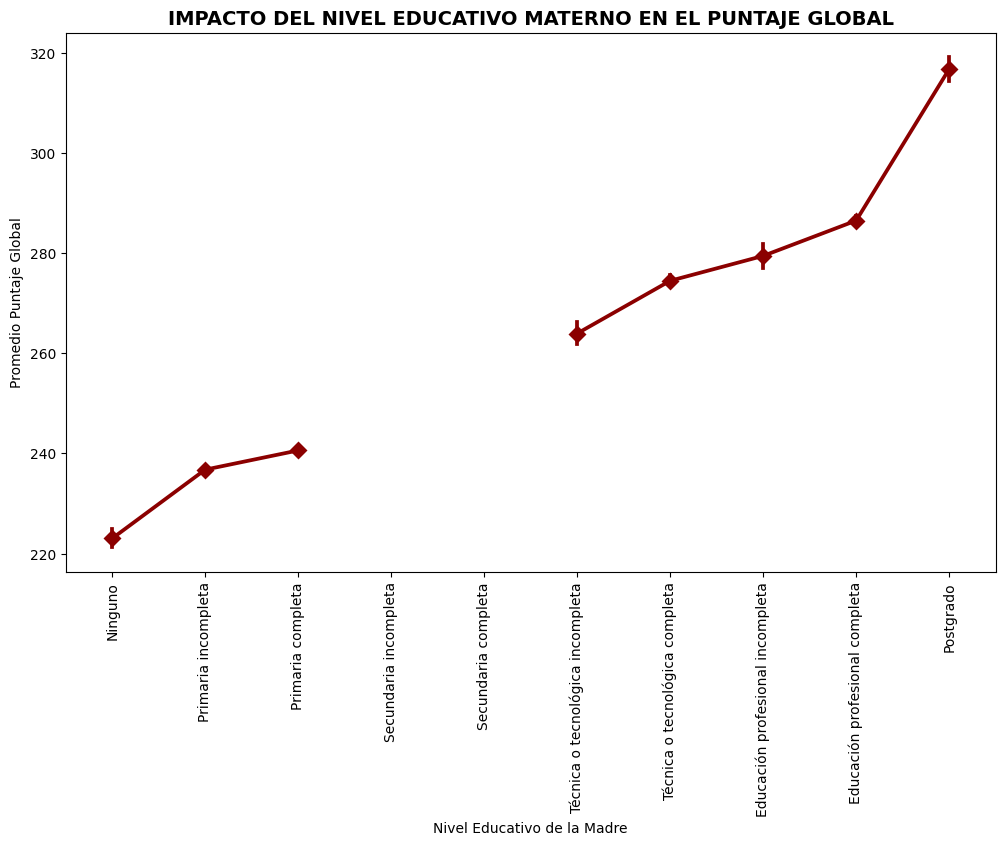

In [30]:
## 10ma Gráfica: Relación entre Educación de la Madre y Éxito Académico
plt.figure(figsize=(12, 7))

# Orden lógico de educación
orden_edu = [
    'Ninguno', 'Primaria incompleta', 'Primaria completa', 
    'Secundaria incompleta', 'Secundaria completa', 
    'Técnica o tecnológica incompleta', 'Técnica o tecnológica completa', 
    'Educación profesional incompleta', 'Educación profesional completa', 'Postgrado'
]

sns.pointplot(data=df_analisis, x='educacion_madre', y='puntaje_global', order=orden_edu, color='darkred', markers='D')

plt.title('IMPACTO DEL NIVEL EDUCATIVO MATERNO EN EL PUNTAJE GLOBAL', fontsize=14, fontweight='bold')
plt.xticks(rotation=90)
plt.xlabel('Nivel Educativo de la Madre')
plt.ylabel('Promedio Puntaje Global')
plt.show()

# Conclusión:
# Esta gráfica muestra el "techo de cristal". Si la pendiente es muy empinada, significa que en el Huila 
# el origen social determina el destino académico, sugiriendo que el sistema escolar no está logrando 
# compensar las desigualdades del hogar.

### **Gráfica 11:** Análisis Consolidado Familia-Territorio

**Sinergia de impacto parental y ubicación geográfica**

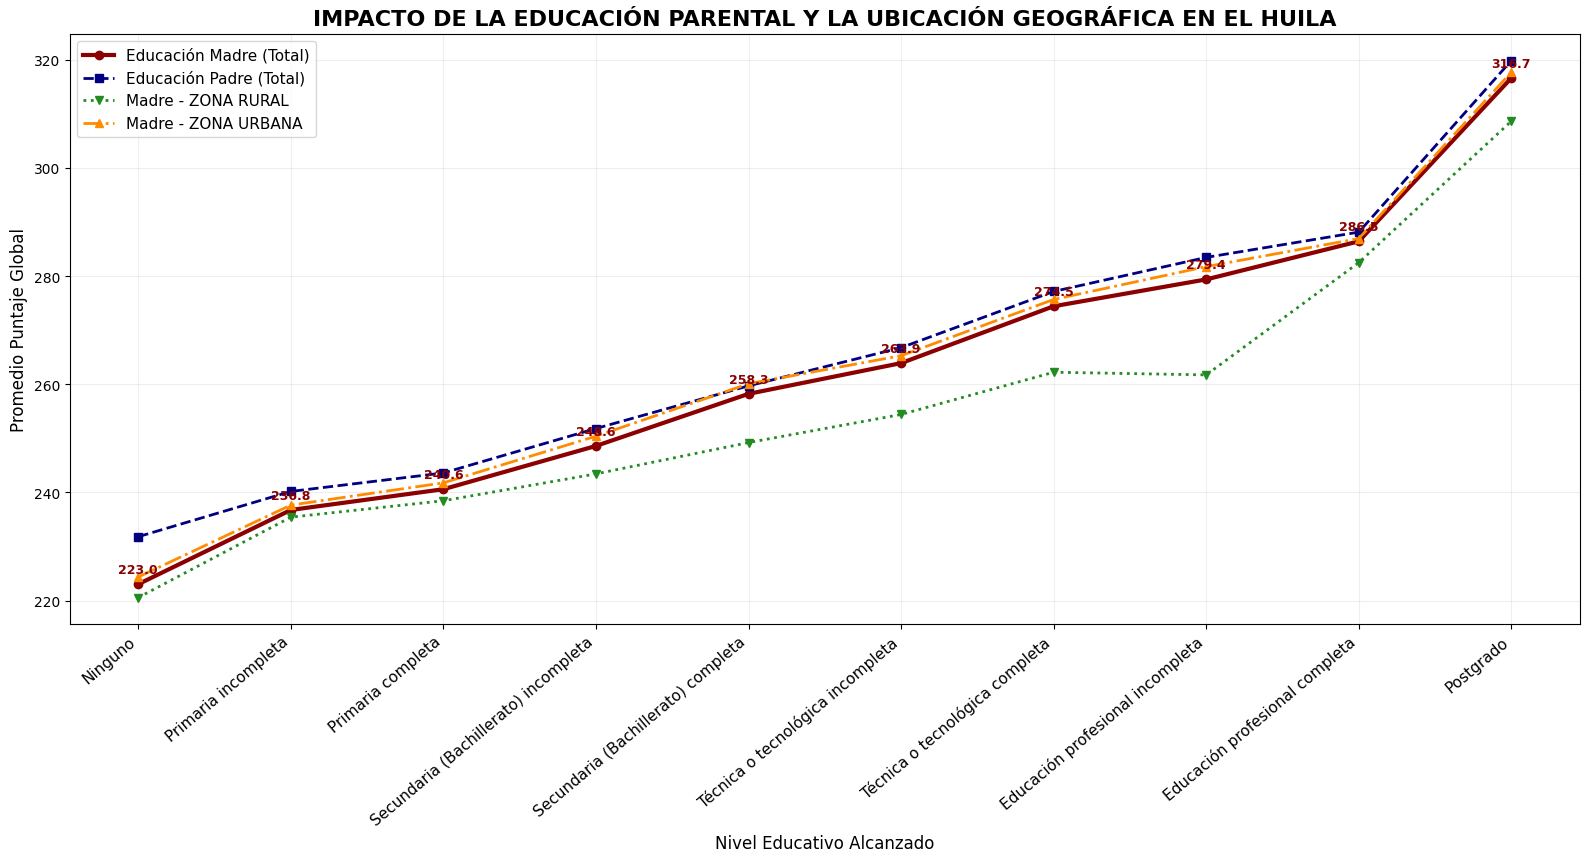

In [29]:
# 1. Definición del orden lógico corregido (según etiquetas reales del dataset)
orden_edu = [
    'Ninguno', 
    'Primaria incompleta', 
    'Primaria completa', 
    'Secundaria (Bachillerato) incompleta', 
    'Secundaria (Bachillerato) completa', 
    'Técnica o tecnológica incompleta', 
    'Técnica o tecnológica completa', 
    'Educación profesional incompleta', 
    'Educación profesional completa', 
    'Postgrado'
]

# 2. Cálculo de las 4 series de datos
# Serie 1: Promedio General por Educación de la Madre
madre_total = df_analisis.groupby('educacion_madre')['puntaje_global'].mean().reindex(orden_edu)

# Serie 2: Promedio General por Educación del Padre
padre_total = df_analisis.groupby('educacion_padre')['puntaje_global'].mean().reindex(orden_edu)

# Serie 3: Promedio Educación Madre - Zona Rural
madre_rural = df_analisis[df_analisis['area_colegio'] == 'RURAL'].groupby('educacion_madre')['puntaje_global'].mean().reindex(orden_edu)

# Serie 4: Promedio Educación Madre - Zona Urbana
madre_urbana = df_analisis[df_analisis['area_colegio'] == 'URBANO'].groupby('educacion_madre')['puntaje_global'].mean().reindex(orden_edu)

# 3. Creación del gráfico consolidado
plt.figure(figsize=(16, 9))

# Trazado de líneas con estilos diferenciados
plt.plot(madre_total.index, madre_total.values, marker='o', label='Educación Madre (Total)', color='darkred', linewidth=3)
plt.plot(padre_total.index, padre_total.values, marker='s', label='Educación Padre (Total)', color='navy', linewidth=2, linestyle='--')
plt.plot(madre_rural.index, madre_rural.values, marker='v', label='Madre - ZONA RURAL', color='forestgreen', linewidth=2, linestyle=':')
plt.plot(madre_urbana.index, madre_urbana.values, marker='^', label='Madre - ZONA URBANA', color='darkorange', linewidth=2, linestyle='-.')

# 4. Ajustes de formato y etiquetas de datos (opcional para no saturar)
for i, v in enumerate(madre_total.values):
    if not np.isnan(v):
        plt.text(i, v + 2, f'{v:.1f}', ha='center', fontsize=9, color='darkred', fontweight='bold')

# 5. Estética final y corrección de márgenes
plt.title('IMPACTO DE LA EDUCACIÓN PARENTAL Y LA UBICACIÓN GEOGRÁFICA EN EL HUILA', fontsize=16, fontweight='bold')
plt.xticks(rotation=40, ha='right', fontsize=11)
plt.ylabel('Promedio Puntaje Global', fontsize=12)
plt.xlabel('Nivel Educativo Alcanzado', fontsize=12)
plt.legend(fontsize=11, loc='upper left', frameon=True)
plt.grid(True, alpha=0.2)

# Ajuste crítico para que no se corten las etiquetas largas
plt.tight_layout()
plt.subplots_adjust(bottom=0.3) 

plt.show()

### **Gráfica 12**

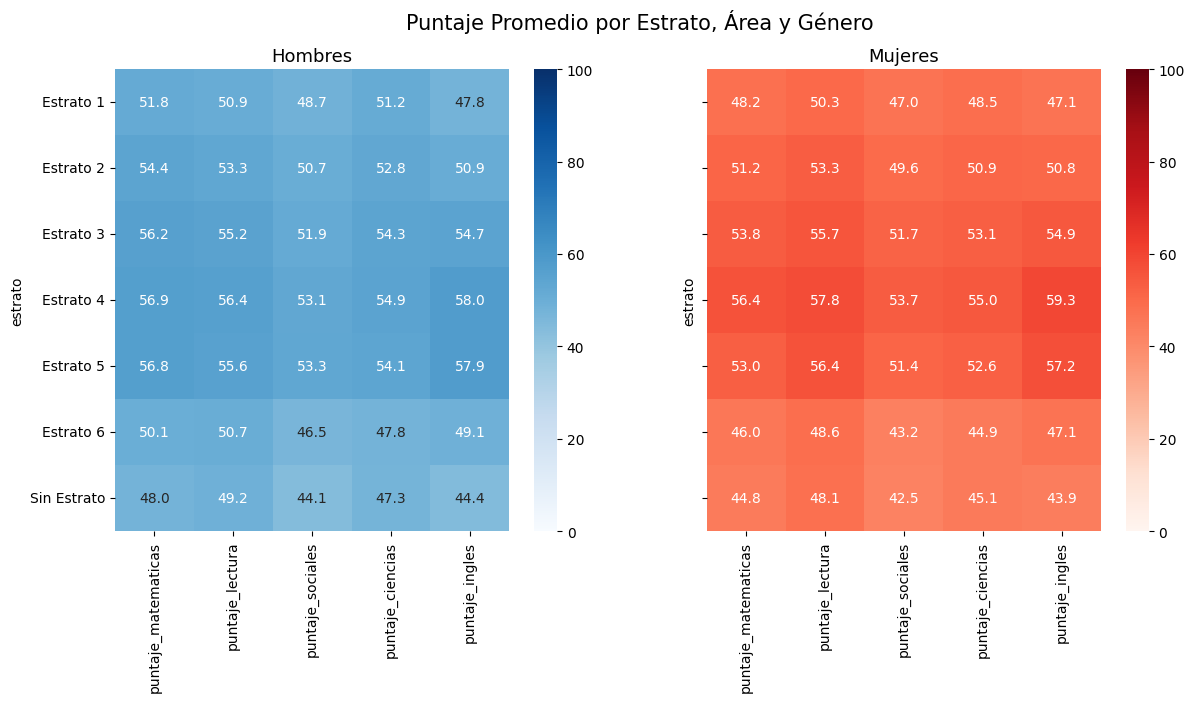

In [5]:
areas = [
    'puntaje_matematicas',
    'puntaje_lectura',
    'puntaje_sociales',
    'puntaje_ciencias',
    'puntaje_ingles'
]

df_group = (
    df_analisis.groupby(['estrato', 'genero'])[areas]
    .mean()
    .reset_index()
)

df_hombres = df_group[df_group['genero'] == 'M'].set_index('estrato')
df_mujeres = df_group[df_group['genero'] == 'F'].set_index('estrato')

df_hombres = df_hombres[areas]
df_mujeres = df_mujeres[areas]

fig, axes = plt.subplots(1, 2, figsize=(14,6), sharey=True)

#Hombres
sns.heatmap(
    df_hombres,
    annot=True,
    cmap="Blues",
    vmin=0,
    vmax=100,
    fmt=".1f",
    ax=axes[0]
)
axes[0].set_title("Hombres", fontsize=13)

#Mujeres
sns.heatmap(
    df_mujeres,
    annot=True,
    cmap="Reds",
    vmin=0,
    vmax=100,
    fmt=".1f",
    ax=axes[1]
)
axes[1].set_title("Mujeres", fontsize=13)

plt.suptitle("Puntaje Promedio por Estrato, Área y Género", fontsize=15)
plt.show()

In [7]:
# Contar cantidad de registros por estrato
conteo_estrato = df_analisis['estrato'].value_counts().sort_index()

print(conteo_estrato)

# Promedio por cada área
promedios_areas = df_analisis[['puntaje_matematicas',
                      'puntaje_ciencias',
                      'puntaje_sociales',
                      'puntaje_ingles',
                      'puntaje_lectura']].mean()

print(promedios_areas)



estrato
Estrato 1      54448
Estrato 2      40084
Estrato 3       7969
Estrato 4       2220
Estrato 5        654
Estrato 6        319
Sin Estrato     1427
Name: count, dtype: int64
puntaje_matematicas    51.139912
puntaje_ciencias       50.603123
puntaje_sociales       48.822511
puntaje_ingles         49.314275
puntaje_lectura        51.985415
dtype: float64


In [9]:
promedio_por_estrato = df_analisis.groupby('estrato')[[
    'puntaje_matematicas',
                      'puntaje_ciencias',
                      'puntaje_sociales',
                      'puntaje_ingles',
                      'puntaje_lectura'
]].mean()

print(promedio_por_estrato)

             puntaje_matematicas  puntaje_ciencias  puntaje_sociales  \
estrato                                                                
Estrato 1              49.664855         49.604558         47.723241   
Estrato 2              52.681594         51.792037         50.114809   
Estrato 3              55.049567         53.703476         51.780148   
Estrato 4              56.671622         54.950901         53.419820   
Estrato 5              54.740061         53.311927         52.218654   
Estrato 6              47.849530         46.253918         44.742947   
Sin Estrato            46.042747         45.962859         43.109320   

             puntaje_ingles  puntaje_lectura  
estrato                                       
Estrato 1         47.374329        50.555649  
Estrato 2         50.833533        53.277941  
Estrato 3         54.795104        55.433053  
Estrato 4         58.658108        57.137387  
Estrato 5         57.532110        56.038226  
Estrato 6         48.0

## PREGUNTAS

**PREGUNTA 1:** 

- ¿Prevalece la brecha territorial (urbano/rural) sobre el nivel socioeconómico como factor determinante del rendimiento académico en el departamento del Huila?

- Responsable: Juan Nicolás Hidalgo

**PREGUNTA 2:** 

- ¿En qué municipios de Huila debe focalizarse la mayor inversión educativa para mitigar el impacto de la vulnerabilidad socioeconómica y cerrar las brechas de aprendizaje?

- Responsable: Gabriel Juan De Dios

**PREGUNTA 3:** 

- ¿El género y el nivel socioeconómico generan brechas significativas en el desempeño académico en las pruebas saber 11 en el departamento del Huila?

- Responsable: Juan Sebastián Méndez Martínez 